<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula11b_PCA_compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.decomposition import PCA
import numpy as np
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
print(d)

154


In [6]:
print(X_train.shape[1] - d)
print(d/X_train.shape[1])

630
0.19642857142857142


In [7]:
pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train)
print(pca.explained_variance_ratio_.sum())

0.9501960192613031


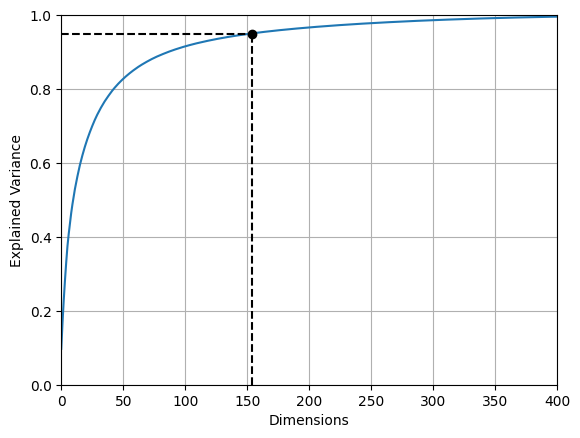

In [12]:
import matplotlib.pyplot as plt

plt.plot(cumsum)
plt.axis([0, 400, 0 ,1])
plt.xlabel('Dimensions')
plt.ylabel('Explained Variance')
plt.plot([d, d], [0, 0.95], 'k--')
plt.plot([0, d], [0.95, 0.95], 'k--')
plt.plot(d, 0.95, 'ko')
plt.grid()
plt.show()

In [13]:
X_test_reduced = pca.transform(X_test)

In [16]:
from sklearn.linear_model import RidgeClassifier
model = RidgeClassifier()

model.fit(X_train, y_train)
print(model.score(X_test, y_test))
print()

model.fit(X_train_reduced, y_train)
print(model.score(X_test_reduced, y_test))

0.8603

0.8609


In [17]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

model.fit(X_train, y_train)
print(model.score(X_test, y_test))
print()

model.fit(X_train_reduced, y_train)
print(model.score(X_test_reduced, y_test))

0.9705

0.9463


# PCA for Compression

In [18]:
X_train_recovered = pca.inverse_transform(X_train_reduced)
print(X_train_recovered.shape)

(60000, 784)


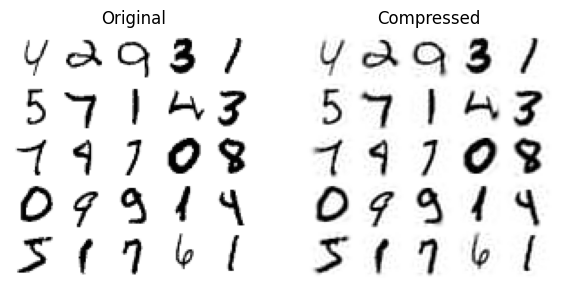

In [23]:
plt.figure(figsize=(7, 4))
for idx, X in enumerate(([X_train[::2100], X_train_recovered[::2100]])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row+1, col, col+1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")
plt.show()